# Pruning Analysis Notebook

This notebook analyzes pruning experiments data from Weights & Biases, comparing the performance of different pruning strategies on various datasets. The analysis focuses on the relationship between communication overhead and model performance.

## Import Required Libraries

Import necessary libraries including pandas, numpy, matplotlib, wandb, and tqdm for data processing and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm
import wandb

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Setup Weights & Biases API Connection

Initialize the Weights & Biases API connection and define project parameters for accessing experiment data.

In [2]:
# Initialize Weights & Biases API
api = wandb.Api()

# Project configuration
ENTITY = "distributed_transformer"
PROJECT_INTER_DEVICE = "pruningV3"
PROJECT_NORMAL = "pruningV3_normal"
PROJECT_INTER_DEVICE_TOTAL = "pruningV3_total"
PROBABILITY_THRESHOLD = 0.0

print("W&B API initialized successfully")

W&B API initialized successfully


## Define Data Loading Functions

Create functions to load experiment data from W&B runs, filter by probability thresholds, and extract relevant metrics.

In [3]:
def load_pruning_data(pruning_type: str = "normal"):
    """
    Load pruning experiment data from Weights & Biases.
    
    Args:
        pruning_type (str): Type of pruning - "normal", "inter_device", or "inter_device_total"
    
    Returns:
        dict: Dictionary containing data organized by dataset and communication parameters
    """
    if pruning_type == "normal":
        project = PROJECT_NORMAL
    elif pruning_type == "inter_device":
        project = PROJECT_INTER_DEVICE
    elif pruning_type == "inter_device_total":
        project = PROJECT_INTER_DEVICE_TOTAL
    else:
        raise ValueError(f"Unknown pruning type: {pruning_type}")
    
    runs = api.runs(ENTITY + "/" + project)
    
    data = {}
    
    for run in tqdm(runs, desc=f"Loading {pruning_type} pruning data"):
        # Get test loss data
        data_single = run.history(samples=10000, keys=["test_loss"])
        if "test_loss" not in data_single.columns:
            continue
        
        # Filter out runs that do not match the desired probability
        if abs(run.config["model"]["partial_layer_dropout_prob"] - PROBABILITY_THRESHOLD) > 0.01:
            continue
            
        dataset = run.config["dataset"]["name"]
        
        if dataset not in data:
            data[dataset] = {}
        
        # Determine amount of communication based on pruning type
        communication_saving = None
        if pruning_type == "normal":
            communication_saving = (128 - run.config["model"]["num_features_attention"]) / 128
        elif pruning_type in ["inter_device", "inter_device_total"]:
            if "pruning_step" not in run.config:
                continue
            communication_saving = run.config["pruning_step"] * run.config["per_step_pruning_ratio"]
        
        # Add data point
        if communication_saving not in data[dataset]:
            data[dataset][communication_saving] = [data_single["test_loss"].iloc[0]]
        else:
            data[dataset][communication_saving].append(data_single["test_loss"].iloc[0])
    
    return data

def calculate_statistics(data_dict):
    """
    Calculate mean, min, and max statistics for the loaded data.
    
    Args:
        data_dict (dict): Dictionary containing raw data points
    
    Returns:
        dict: Dictionary with calculated statistics
    """
    stats = {}
    for dataset in data_dict:
        stats[dataset] = {}
        for comm_saving in data_dict[dataset]:
            values = data_dict[dataset][comm_saving]
            stats[dataset][comm_saving] = {
                'mean': np.mean(values),
                'min': np.min(values),
                'max': np.max(values),
                'std': np.std(values),
                'count': len(values)
            }
    return stats

## Load Pruning Data from Experiments

Execute data loading for both inter-device and normal pruning experiments, collecting test loss data from multiple runs.

In [4]:
# Load normal pruning data
print("Loading normal pruning data...")
normal_pruning_data = load_pruning_data(pruning_type="normal")

# Display summary of loaded data
print(f"\nNormal pruning datasets: {list(normal_pruning_data.keys())}")

# Show data structure for one dataset
if normal_pruning_data:
    first_dataset = list(normal_pruning_data.keys())[0]
    print(f"\nExample - Normal pruning data structure for '{first_dataset}':")
    for comm_level, values in normal_pruning_data[first_dataset].items():
        print(f"  Communication level {comm_level}: {len(values)} runs")

Loading normal pruning data...


Loading normal pruning data: 100%|██████████| 422/422 [04:13<00:00,  1.66it/s]


Normal pruning datasets: ['ETT', 'ICD', 'traffic_hourly_dataset', 'london_smart_meters_dataset']

Example - Normal pruning data structure for 'ETT':
  Communication level 0.0: 20 runs
  Communication level 0.125: 10 runs
  Communication level 0.25: 10 runs
  Communication level 0.375: 10 runs
  Communication level 0.5: 20 runs
  Communication level 0.625: 10 runs
  Communication level 0.75: 10 runs
  Communication level 0.875: 20 runs


In [5]:
# Load inter-device total pruning data
print("Loading inter-device total pruning data...")
inter_device_total_pruning_data = load_pruning_data(pruning_type="inter_device_total")

# Display summary of loaded data
print(f"\nInter-device total pruning datasets: {list(inter_device_total_pruning_data.keys())}")

# Show data structure for one dataset
if inter_device_total_pruning_data:
    first_dataset = list(inter_device_total_pruning_data.keys())[0]
    print(f"\nExample - Inter-device total pruning data structure for '{first_dataset}':")
    for comm_level, values in inter_device_total_pruning_data[first_dataset].items():
        print(f"  Communication level {comm_level}: {len(values)} runs")

Loading inter-device total pruning data...


Loading inter_device_total pruning data: 100%|██████████| 345/345 [03:06<00:00,  1.85it/s]


Inter-device total pruning datasets: ['ETT', 'traffic_hourly_dataset', 'london_smart_meters_dataset', 'ICD']

Example - Inter-device total pruning data structure for 'ETT':
  Communication level 0.0: 10 runs
  Communication level 0.1: 10 runs
  Communication level 0.2: 10 runs
  Communication level 0.30000000000000004: 10 runs
  Communication level 0.4: 10 runs
  Communication level 0.5: 10 runs
  Communication level 0.6000000000000001: 10 runs
  Communication level 0.7000000000000001: 10 runs
  Communication level 0.8: 10 runs
  Communication level 0.9: 10 runs
  Communication level 1.0: 10 runs


In [6]:
# Load inter-device pruning data
print("Loading inter-device pruning data...")
inter_device_pruning_data = load_pruning_data(pruning_type="inter_device")

# Display summary of loaded data
print(f"\nInter-device pruning datasets: {list(inter_device_pruning_data.keys())}")

# Show data structure for one dataset
if inter_device_pruning_data:
    first_dataset = list(inter_device_pruning_data.keys())[0]
    print(f"\nExample - Inter-device pruning data structure for '{first_dataset}':")
    for comm_level, values in inter_device_pruning_data[first_dataset].items():
        print(f"  Communication level {comm_level}: {len(values)} runs")

Loading inter-device pruning data...


Loading inter_device pruning data: 100%|██████████| 440/440 [04:21<00:00,  1.68it/s]


Inter-device pruning datasets: ['ETT', 'ICD', 'traffic_hourly_dataset', 'london_smart_meters_dataset']

Example - Inter-device pruning data structure for 'ETT':
  Communication level 0.0: 10 runs
  Communication level 0.1: 10 runs
  Communication level 0.2: 10 runs
  Communication level 0.30000000000000004: 10 runs
  Communication level 0.4: 10 runs
  Communication level 0.5: 10 runs
  Communication level 0.6000000000000001: 10 runs
  Communication level 0.7000000000000001: 10 runs
  Communication level 0.8: 10 runs
  Communication level 0.9: 10 runs
  Communication level 1.0: 10 runs


## Process and Structure the Data

Organize the loaded data by dataset and communication parameters, calculating statistics and preparing data structures for visualization.

In [7]:
# Calculate statistics for all three datasets
normal_pruning_stats = calculate_statistics(normal_pruning_data)
inter_device_pruning_stats = calculate_statistics(inter_device_pruning_data)
inter_device_total_pruning_stats = calculate_statistics(inter_device_total_pruning_data)

# Create combined data structure for comparison
all_data = {
    'Normal Pruning': normal_pruning_data,
    'Inter-Device Pruning': inter_device_pruning_data,
    'Inter-Device Total Pruning': inter_device_total_pruning_data
}

all_stats = {
    'Normal Pruning': normal_pruning_stats,
    'Inter-Device Pruning': inter_device_pruning_stats,
    'Inter-Device Total Pruning': inter_device_total_pruning_stats
}

# Display statistics summary
print("Data Processing Complete!")
print("\nStatistics Summary:")
for pruning_type, stats in all_stats.items():
    print(f"\n{pruning_type}:")
    for dataset in stats:
        comm_levels = len(stats[dataset])
        total_runs = sum(stats[dataset][comm]['count'] for comm in stats[dataset])
        print(f"  {dataset}: {comm_levels} communication levels, {total_runs} total runs")

Data Processing Complete!

Statistics Summary:

Normal Pruning:
  ETT: 8 communication levels, 110 total runs
  ICD: 8 communication levels, 84 total runs
  traffic_hourly_dataset: 8 communication levels, 110 total runs
  london_smart_meters_dataset: 8 communication levels, 110 total runs

Inter-Device Pruning:
  ETT: 11 communication levels, 110 total runs
  ICD: 11 communication levels, 110 total runs
  traffic_hourly_dataset: 11 communication levels, 110 total runs
  london_smart_meters_dataset: 11 communication levels, 110 total runs

Inter-Device Total Pruning:
  ETT: 11 communication levels, 110 total runs
  traffic_hourly_dataset: 11 communication levels, 69 total runs
  london_smart_meters_dataset: 11 communication levels, 101 total runs
  ICD: 6 communication levels, 48 total runs


## Define Plotting Functions

Create plotting functions that generate shaded area plots showing mean, min, and max values across different communication levels.

In [8]:
def plot_shaded_area(data_dict, label, color=None, alpha=0.3):
    """
    Plot shaded area chart showing mean with min/max bounds.
    
    Args:
        data_dict (dict): Dictionary with communication levels as keys and loss lists as values
        label (str): Label for the plot legend
        color: Color for the plot (optional)
        alpha (float): Transparency for the shaded area
    """
    if not data_dict:
        return None, None, None, None
    
    # Sort communication levels and calculate statistics
    comm_saving = sorted(data_dict.keys())
    loss_values = [data_dict[s] for s in comm_saving]
    means = [np.mean(losses) for losses in loss_values]
    mins = [np.min(losses) for losses in loss_values]
    maxs = [np.max(losses) for losses in loss_values]
    
    # Create plot
    line = plt.plot(comm_saving, means, label=label, color=color, marker='o', linewidth=2)
    color = line[0].get_color()  # Get the actual color used
    plt.fill_between(comm_saving, mins, maxs, alpha=alpha, color=color)
    
    return comm_saving, means, mins, maxs

def create_comparison_plot(dataset_name, normal_data, inter_device_data, inter_device_total_data, save_csv=False):
    """
    Create a comparison plot for a specific dataset showing all three pruning strategies.
    
    Args:
        dataset_name (str): Name of the dataset to plot
        normal_data (dict): Normal pruning data for the dataset
        inter_device_data (dict): Inter-device pruning data for the dataset
        inter_device_total_data (dict): Inter-device total pruning data for the dataset
        save_csv (bool): Whether to save data to CSV files
    """
    plt.figure(figsize=(12, 8))
    
    # Plot normal pruning data
    normal_stats = plot_shaded_area(
        normal_data, 
        'Normal Pruning', 
        color='blue'
    )
    
    # Plot inter-device pruning data
    inter_device_stats = plot_shaded_area(
        inter_device_data, 
        'Inter-Device Pruning', 
        color='red'
    )
    
    # Plot inter-device total pruning data
    inter_device_total_stats = plot_shaded_area(
        inter_device_total_data, 
        'Inter-Device Total Pruning', 
        color='green'
    )
    
    # Customize plot
    plt.xlabel('Number of Communications', fontsize=14)
    plt.ylabel('Test Loss', fontsize=14)
    plt.title(f'Pruning Strategy Comparison - Dataset: {dataset_name}', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Save to CSV if requested
    if save_csv and normal_stats[0] is not None:
        save_data_to_csv(dataset_name, normal_stats, 'normal_pruning')
    if save_csv and inter_device_stats[0] is not None:
        save_data_to_csv(dataset_name, inter_device_stats, 'inter_device_pruning')
    if save_csv and inter_device_total_stats[0] is not None:
        save_data_to_csv(dataset_name, inter_device_total_stats, 'inter_device_total_pruning')
    
    plt.tight_layout()
    plt.show()

def save_data_to_csv(dataset_name, stats_tuple, pruning_type):
    """
    Save plotting data to CSV file.
    
    Args:
        dataset_name (str): Name of the dataset
        stats_tuple (tuple): Tuple containing (communication_levels, means, mins, maxs)
        pruning_type (str): Type of pruning strategy
    """
    comm_saving, means, mins, maxs = stats_tuple
    
    df = pd.DataFrame({
        "communication_savings": list(np.array(comm_saving) * 100),
        "mean_loss": means,
        "min_loss": mins,
        "max_loss": maxs
    })
    
    filename = f"{dataset_name}_{pruning_type}_vs_communication.csv"
    filepath = f"/home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/{filename}"
    df.to_csv(filepath, index=False)
    print(f"Data saved to: {filepath}")

def plot_all_datasets(all_data_dict, save_csv=False):
    """
    Create plots for all available datasets.
    
    Args:
        all_data_dict (dict): Dictionary containing all pruning data
        save_csv (bool): Whether to save data to CSV files
    """
    # Get all unique datasets
    all_datasets = set()
    for pruning_type in all_data_dict:
        all_datasets.update(all_data_dict[pruning_type].keys())
    
    print(f"Creating plots for {len(all_datasets)} datasets...")
    
    for dataset in sorted(all_datasets):
        normal_data = all_data_dict.get('Normal Pruning', {}).get(dataset, {})
        inter_device_data = all_data_dict.get('Inter-Device Pruning', {}).get(dataset, {})
        inter_device_total_data = all_data_dict.get('Inter-Device Total Pruning', {}).get(dataset, {})
        
        if normal_data or inter_device_data or inter_device_total_data:
            create_comparison_plot(dataset, normal_data, inter_device_data, inter_device_total_data, save_csv)
        else:
            print(f"No data available for dataset: {dataset}")

## Create Visualization Plots

Generate comparison plots for different datasets and pruning strategies, displaying the relationship between communication and loss.

Creating plots for 4 datasets...
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_normal_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_inter_device_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ETT_inter_device_total_pruning_vs_communication.csv


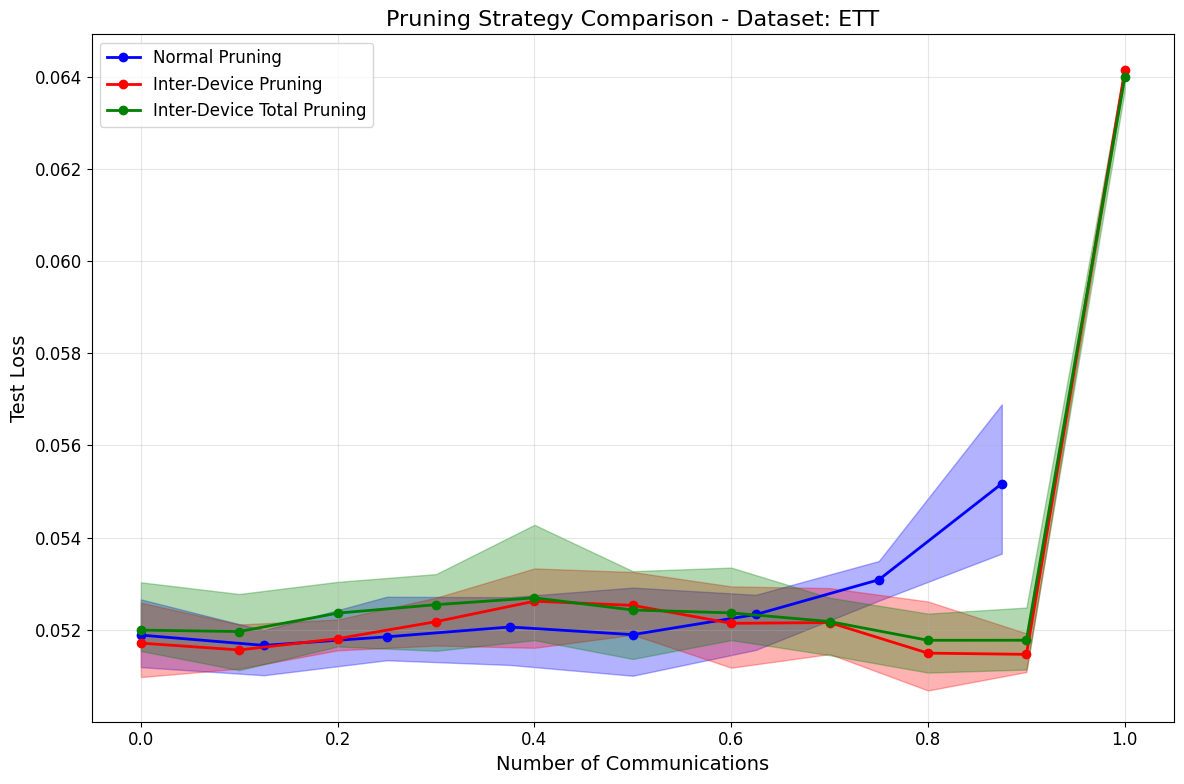

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_normal_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_inter_device_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/ICD_inter_device_total_pruning_vs_communication.csv


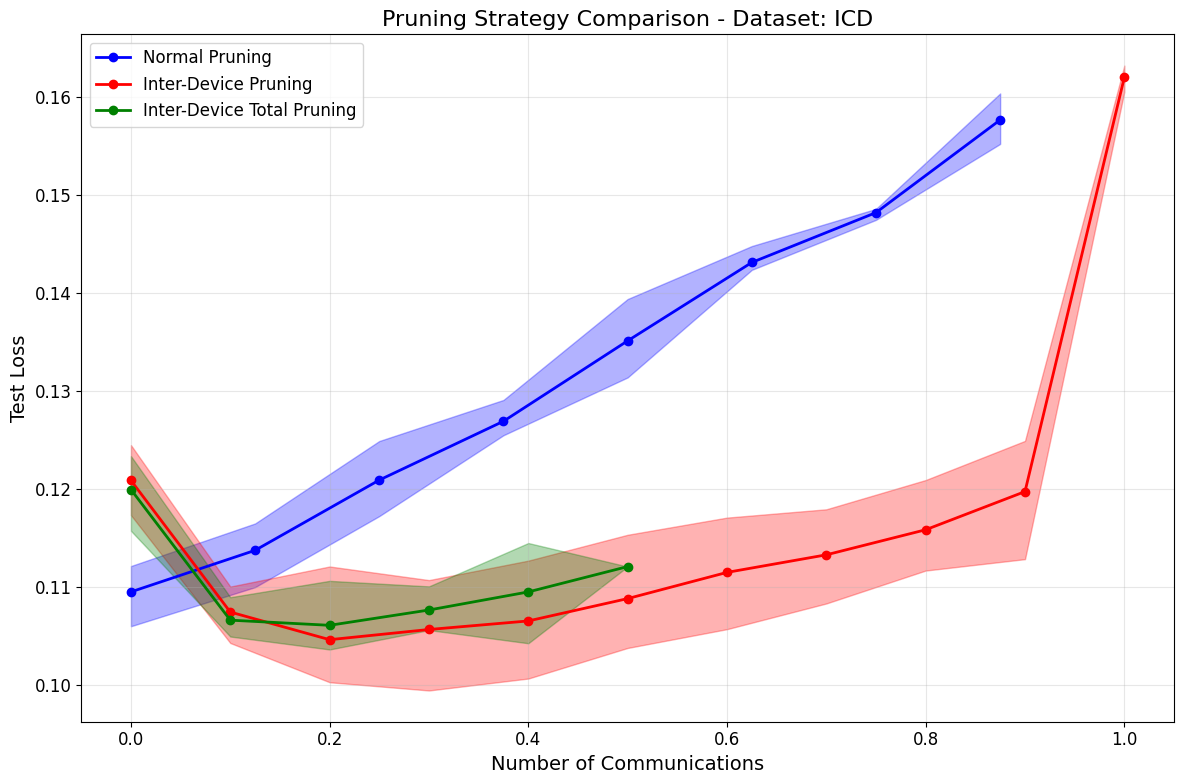

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_normal_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_inter_device_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/london_smart_meters_dataset_inter_device_total_pruning_vs_communication.csv


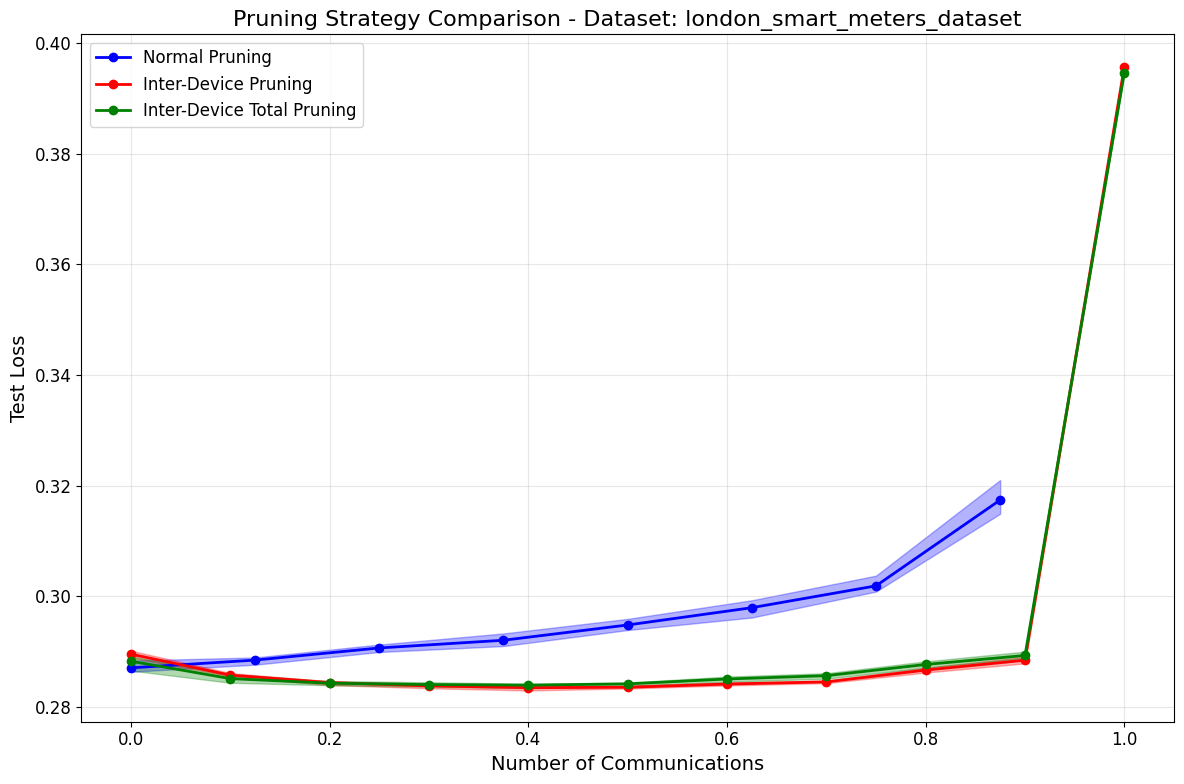

Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_normal_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_inter_device_pruning_vs_communication.csv
Data saved to: /home/alex/Documents/009_Paper/papers-dsme-nes/distributed_neural_network_inference/plot_data/traffic_hourly_dataset_inter_device_total_pruning_vs_communication.csv


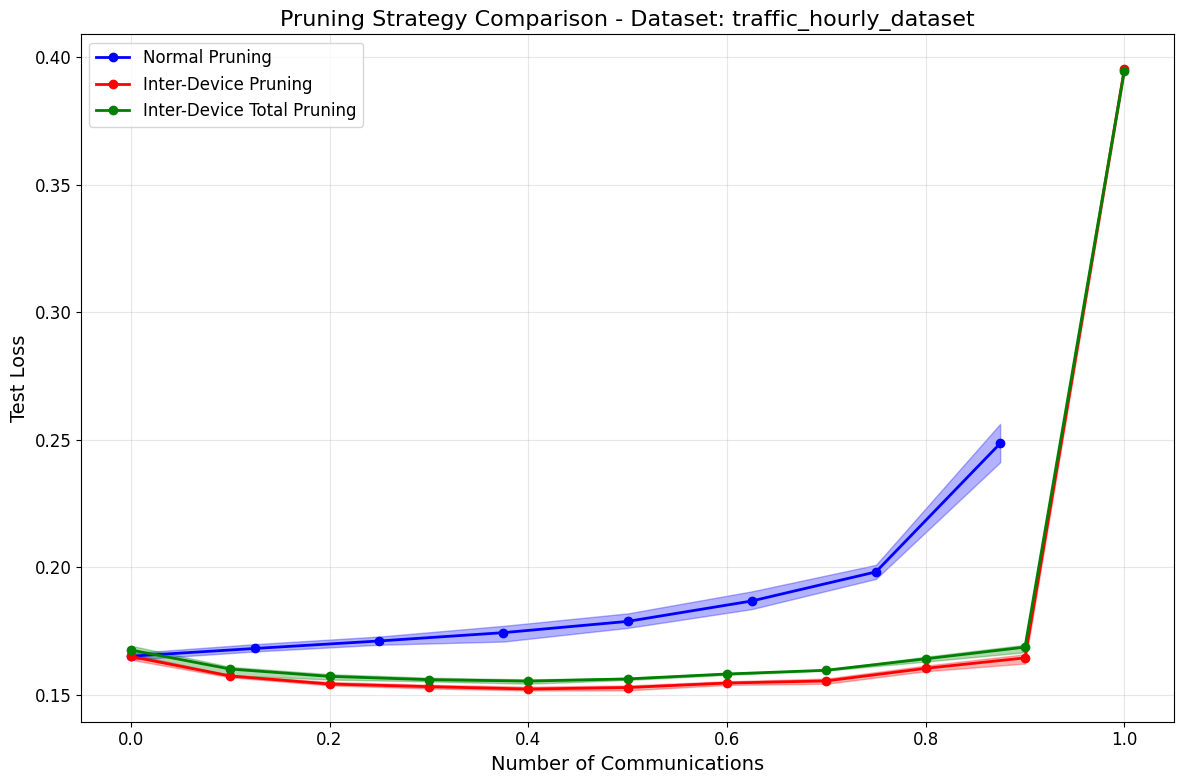

In [9]:
# Create plots for all datasets
plot_all_datasets(all_data, save_csv=True)

## Individual Dataset Analysis

You can also create plots for specific datasets by running the cells below. Modify the dataset name to analyze different datasets individually.

Available datasets:
  - ETT
  - ICD
  - london_smart_meters_dataset
  - traffic_hourly_dataset

Plotting dataset: ETT


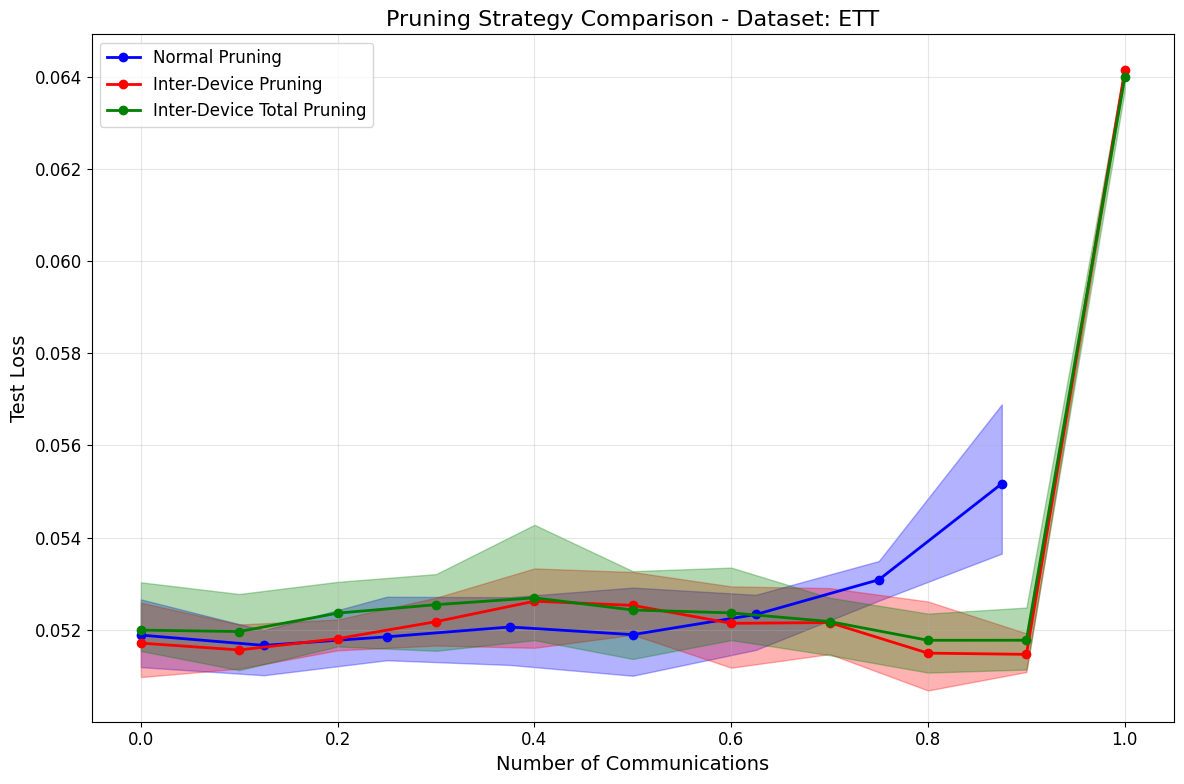

In [10]:
# Example: Plot a specific dataset
# Change this to any dataset name from the loaded data
available_datasets = set()
for pruning_type in all_data:
    available_datasets.update(all_data[pruning_type].keys())

print("Available datasets:")
for dataset in sorted(available_datasets):
    print(f"  - {dataset}")

# Select a dataset to plot (change this as needed)
if available_datasets:
    selected_dataset = list(sorted(available_datasets))[0]  # Pick the first dataset
    print(f"\nPlotting dataset: {selected_dataset}")
    
    normal_data = all_data.get('Normal Pruning', {}).get(selected_dataset, {})
    inter_device_data = all_data.get('Inter-Device Pruning', {}).get(selected_dataset, {})
    inter_device_total_data = all_data.get('Inter-Device Total Pruning', {}).get(selected_dataset, {})
    
    create_comparison_plot(selected_dataset, normal_data, inter_device_data, inter_device_total_data, save_csv=False)
else:
    print("No datasets available to plot.")

## Data Summary and Statistics

Display detailed statistics about the loaded experiment data.

In [11]:
# Display detailed statistics
print("="*60)
print("DETAILED STATISTICS SUMMARY")
print("="*60)

for pruning_type, stats in all_stats.items():
    print(f"\n{pruning_type.upper()}:")
    print("-" * 40)
    
    for dataset in sorted(stats.keys()):
        print(f"\nDataset: {dataset}")
        dataset_stats = stats[dataset]
        
        for comm_level in sorted(dataset_stats.keys()):
            stat = dataset_stats[comm_level]
            print(f"  Communication Level {comm_level:.2f}:")
            print(f"    Runs: {stat['count']}")
            print(f"    Mean Loss: {stat['mean']:.4f}")
            print(f"    Std Dev: {stat['std']:.4f}")
            print(f"    Min Loss: {stat['min']:.4f}")
            print(f"    Max Loss: {stat['max']:.4f}")

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
summary_data = []

for pruning_type in all_stats:
    for dataset in all_stats[pruning_type]:
        comm_levels = len(all_stats[pruning_type][dataset])
        total_runs = sum(all_stats[pruning_type][dataset][comm]['count'] 
                        for comm in all_stats[pruning_type][dataset])
        avg_loss = np.mean([all_stats[pruning_type][dataset][comm]['mean'] 
                           for comm in all_stats[pruning_type][dataset]])
        
        summary_data.append({
            'Pruning Type': pruning_type,
            'Dataset': dataset,
            'Communication Levels': comm_levels,
            'Total Runs': total_runs,
            'Average Loss': avg_loss
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format='%.4f'))

DETAILED STATISTICS SUMMARY

NORMAL PRUNING:
----------------------------------------

Dataset: ETT
  Communication Level 0.00:
    Runs: 20
    Mean Loss: 0.0519
    Std Dev: 0.0004
    Min Loss: 0.0512
    Max Loss: 0.0527
  Communication Level 0.12:
    Runs: 10
    Mean Loss: 0.0517
    Std Dev: 0.0003
    Min Loss: 0.0510
    Max Loss: 0.0520
  Communication Level 0.25:
    Runs: 10
    Mean Loss: 0.0518
    Std Dev: 0.0004
    Min Loss: 0.0513
    Max Loss: 0.0527
  Communication Level 0.38:
    Runs: 10
    Mean Loss: 0.0521
    Std Dev: 0.0005
    Min Loss: 0.0512
    Max Loss: 0.0527
  Communication Level 0.50:
    Runs: 20
    Mean Loss: 0.0519
    Std Dev: 0.0005
    Min Loss: 0.0510
    Max Loss: 0.0529
  Communication Level 0.62:
    Runs: 10
    Mean Loss: 0.0523
    Std Dev: 0.0004
    Min Loss: 0.0516
    Max Loss: 0.0528
  Communication Level 0.75:
    Runs: 10
    Mean Loss: 0.0531
    Std Dev: 0.0003
    Min Loss: 0.0526
    Max Loss: 0.0535
  Communication Level 0.8